Esquema óptimo convergió en la iteración 32


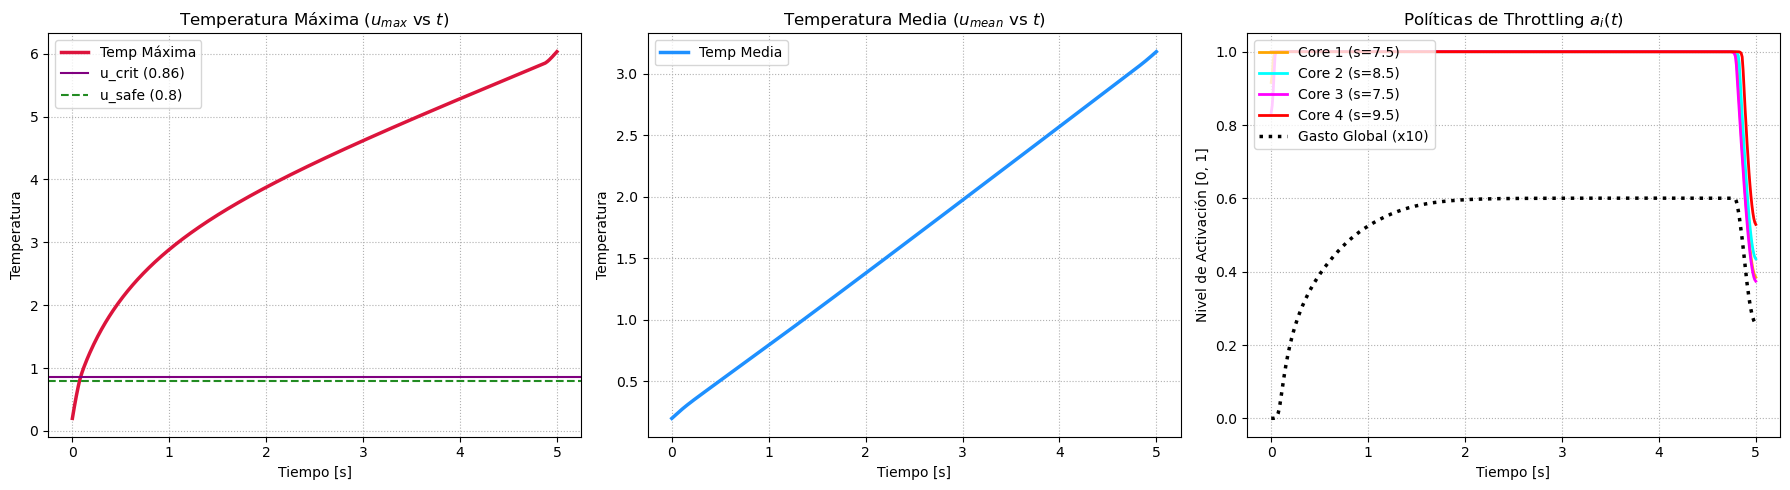

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

def solve_thermal_dvfs_pinn_match():
    # --- Parámetros de la Política DVFS (Basado en el Documento) ---
    nx, ny = 40, 40
    total_time = 5.0
    dt = 0.01
    nt = int(total_time / dt)
    dx = dy = 1.0 / (nx - 1)
    
    alpha = 0.008           # Difusividad del sustrato
    u_init = 0.20           # Temperatura inicial
    u_safe = 0.80           # Umbral del gate térmico (activación)
    u_crit = 0.86           # Umbral crítico de daño (penalización)
    k_gate = 15.0           # Pendiente del gate (beta_gate)
    c_max = 0.35            # Reducción máxima del DVFS (35%)
    
    # Pesos del Funcional de Pérdida
    lambda_hs = 20.0        # Peso del hotspot (L_hot)
    lambda_uso = 0.4      # Combinación de costo lineal (L_uso 0.4 + L_sparse 0.5)
    
    # --- Malla Espacial ---
    x = np.linspace(0, 1, nx)
    y = np.linspace(0, 1, ny)
    X, Y = np.meshgrid(x, y)
    
    # --- Fuentes de Calor y Actuadores (4 Núcleos) ---
    centers = [(0.25, 0.25), (0.75, 0.75), (0.60, 0.20), (0.30, 0.70)]
    strengths = [7.5, 8.5, 7.5, 9.5]
    sigma_Q = 0.06
    sigma_c = 0.12
    
    Q = np.zeros((nx, ny))
    phi = np.zeros((4, nx, ny)) # Bases espaciales de los actuadores
    
    for i in range(4):
        cx, cy = centers[i]
        Q += strengths[i] * np.exp(-((X - cx)**2 + (Y - cy)**2) / (2 * sigma_Q**2))
        phi[i] = np.exp(-((X - cx)**2 + (Y - cy)**2) / (sigma_c**2))
        
    # --- Inicialización de variables ---
    u = np.full((nt, nx, ny), u_init)
    p = np.zeros((nt, nx, ny))
    
    # 4 actuadores temporales a_i(t) en [0, 1]
    a = np.zeros((nt, 4)) 
    
    max_iter = 60
    learning_rate = 0.05
    tol = 1e-4

    for it in range(max_iter):
        u_old = u.copy()
        a_old = a.copy()

        # --- 1. Forward Sweep (Estado u) ---
        for t in range(0, nt - 1):
            laplacian = (np.roll(u[t], -1, axis=0) + np.roll(u[t], 1, axis=0) +
                         np.roll(u[t], -1, axis=1) + np.roll(u[t], 1, axis=1) - 
                         4*u[t]) / dx**2
            
            gate = 1.0 / (1.0 + np.exp(-k_gate * (u[t] - u_safe)))
            
            # Control distribuido c(x,y,t) = c_max * sum(a_i * phi_i)
            c_dist = c_max * sum(a[t, i] * phi[i] for i in range(4))
            
            # DVFS actúa multiplicativamente reduciendo Q
            Q_eff = Q * (1.0 - gate * c_dist)
            
            u[t+1] = u[t] + dt * (alpha * laplacian + Q_eff)
            
            # BCs Neumann
            u[t+1, 0, :] = u[t+1, 1, :]
            u[t+1, -1, :] = u[t+1, -2, :]
            u[t+1, :, 0] = u[t+1, :, 1]
            u[t+1, :, -1] = u[t+1, :, -2]

        # --- 2. Backward Sweep (Adjunto p) ---
        for t in range(nt - 1, 0, -1):
            laplacian_p = (np.roll(p[t], -1, axis=0) + np.roll(p[t], 1, axis=0) +
                           np.roll(p[t], -1, axis=1) + np.roll(p[t], 1, axis=1) - 
                           4*p[t]) / dx**2
            
            gate = 1.0 / (1.0 + np.exp(-k_gate * (u[t] - u_safe)))
            dgate_du = k_gate * gate * (1.0 - gate)
            c_dist = c_max * sum(a[t, i] * phi[i] for i in range(4))
            
            # Derivadas para la ecuación adjunta (Política DVFS)
            dQeff_du = -Q * c_dist * dgate_du
            dloss_du = 2.0 * lambda_hs * np.maximum(0, u[t] - u_crit) + lambda_uso * c_dist * dgate_du
            
            p[t-1] = p[t] + dt * (alpha * laplacian_p + p[t] * dQeff_du + dloss_du)
            
            # BCs Neumann para p
            p[t-1, 0, :] = p[t-1, 1, :]
            p[t-1, -1, :] = p[t-1, -2, :]
            p[t-1, :, 0] = p[t-1, :, 1]
            p[t-1, :, -1] = p[t-1, :, -2]

        # --- 3. Actualización Suave de Actuadores (Sobolev Gradient) ---
        for i in range(4):
            grad_a = np.zeros(nt)
            for t in range(nt):
                gate = 1.0 / (1.0 + np.exp(-k_gate * (u[t] - u_safe)))
                
                # Gradiente del Hamiltoniano respecto a a_i(t)
                dH = (lambda_uso * gate - p[t] * Q * gate) * c_max * phi[i]
                grad_a[t] = np.sum(dH) * dx * dy
            
            # Emulamos la penalización L_suav de la PINN aplicando un filtro Gaussiano
            grad_a_smooth = gaussian_filter1d(grad_a, sigma=10)
            
            # Descenso de gradiente y proyección al rango [0, 1]
            a_new = a_old[:, i] - learning_rate * grad_a_smooth
            a_new = np.clip(a_new, 0.0, 1.0)
            a[:, i] = 0.5 * a_new + 0.5 * a_old[:, i]

        error = np.linalg.norm(u - u_old) / (np.linalg.norm(u_old) + 1e-9)
        if error < tol:
            print(f"Esquema óptimo convergió en la iteración {it+1}")
            break

    # --- 4. Extracción de Métricas ---
    time_axis = np.linspace(0, total_time, nt)
    max_temps = np.max(u, axis=(1, 2))
    avg_temps = np.mean(u, axis=(1, 2))
    
    # Gasto de control medio en el chip
    mean_c_eff = np.zeros(nt)
    for t in range(nt):
        gate = 1.0 / (1.0 + np.exp(-k_gate * (u[t] - u_safe)))
        c_dist = c_max * sum(a[t, i] * phi[i] for i in range(4))
        mean_c_eff[t] = np.mean(gate * c_dist)
        
    # --- 5. Gráficas Estilo PINN ---
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    
    # Gráfica 1: Temperatura Máxima
    ax1.plot(time_axis, max_temps, color='crimson', lw=2.5, label='Temp Máxima')
    ax1.axhline(y=u_crit, color='purple', ls='-', lw=1.5, label=f'u_crit ({u_crit})')
    ax1.axhline(y=u_safe, color='forestgreen', ls='--', lw=1.5, label=f'u_safe ({u_safe})')
    ax1.set_title('Temperatura Máxima ($u_{max}$ vs $t$)')
    ax1.set_xlabel('Tiempo [s]')
    ax1.set_ylabel('Temperatura')
    ax1.legend(loc='upper left')
    ax1.grid(True, ls=':')
    
    # Gráfica 2: Temperatura Media
    ax2.plot(time_axis, avg_temps, color='dodgerblue', lw=2.5, label='Temp Media')
    ax2.set_title('Temperatura Media ($u_{mean}$ vs $t$)')
    ax2.set_xlabel('Tiempo [s]')
    ax2.set_ylabel('Temperatura')
    ax2.legend(loc='upper left')
    ax2.grid(True, ls=':')
    
    # Gráfica 3: Políticas de Actuadores Individuales (Nuevas curvas suaves)
    colors = ['orange', 'cyan', 'magenta', 'red']
    for i in range(4):
        ax3.plot(time_axis, a[:, i], color=colors[i], lw=2, label=f'Core {i+1} (s={strengths[i]})')
    ax3.plot(time_axis, mean_c_eff * 10, color='black', lw=2.5, ls=':', label='Gasto Global (x10)')
        
    ax3.set_title('Políticas de Throttling $a_i(t)$')
    ax3.set_xlabel('Tiempo [s]')
    ax3.set_ylabel('Nivel de Activación [0, 1]')
    ax3.legend(loc='upper left')
    ax3.grid(True, ls=':')
    
    plt.tight_layout()
    plt.show()
    
    return u, a

u_res, a_res = solve_thermal_dvfs_pinn_match()